In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
calendar = pd.read_csv("/Users/abhigyanseth/Projects/m5_forecasting/data/calendar.csv")
prices = pd.read_csv("/Users/abhigyanseth/Projects/m5_forecasting/data/sell_prices.csv")
sales = pd.read_csv("/Users/abhigyanseth/Projects/m5_forecasting/data/sales_train_validation.csv")

print("Calendar:")
print(calendar.head(), "\n")

print("Prices:")
print(prices.head(), "\n")

print("Sales:")
print(sales.head(), "\n")

Calendar:
         date  wm_yr_wk    weekday  wday  month  year    d event_name_1  \
0  2011-01-29     11101   Saturday     1      1  2011  d_1          NaN   
1  2011-01-30     11101     Sunday     2      1  2011  d_2          NaN   
2  2011-01-31     11101     Monday     3      1  2011  d_3          NaN   
3  2011-02-01     11101    Tuesday     4      2  2011  d_4          NaN   
4  2011-02-02     11101  Wednesday     5      2  2011  d_5          NaN   

  event_type_1 event_name_2 event_type_2  snap_CA  snap_TX  snap_WI  
0          NaN          NaN          NaN        0        0        0  
1          NaN          NaN          NaN        0        0        0  
2          NaN          NaN          NaN        0        0        0  
3          NaN          NaN          NaN        1        1        0  
4          NaN          NaN          NaN        1        0        1   

Prices:
  store_id        item_id  wm_yr_wk  sell_price
0     CA_1  HOBBIES_1_001     11325        9.58
1     CA_1  H

In [6]:
print("Calendar missing values:\n", calendar.isnull().sum())
print("Sales missing values:\n", sales.isnull().sum())
print("Prices missing values:\n", prices.isnull().sum())

Calendar missing values:
 date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64
Sales missing values:
 id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
           ..
d_1909      0
d_1910      0
d_1911      0
d_1912      0
d_1913      0
Length: 1919, dtype: int64
Prices missing values:
 store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64


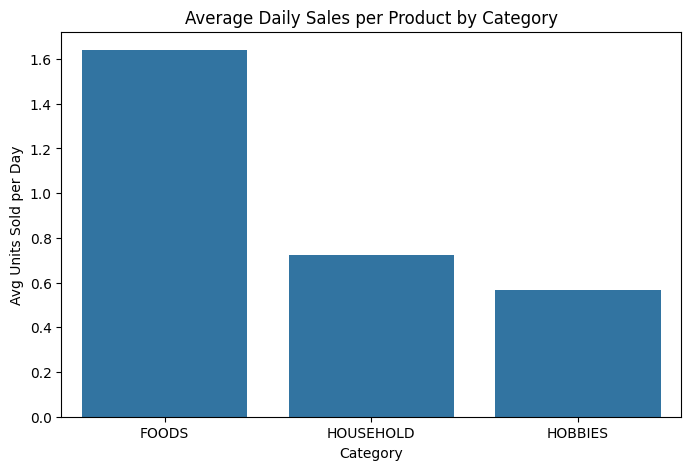

In [17]:
num_days = sales.shape[1] - 6

sales['avg_daily_sales'] = sales.iloc[:, 6:].mean(axis = 1)

avg_cat_sales = sales.groupby('cat_id')['avg_daily_sales'].mean().sort_values(ascending = False)

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_cat_sales.index, y=avg_cat_sales.values)
plt.title("Average Daily Sales per Product by Category")
plt.ylabel("Avg Units Sold per Day")
plt.xlabel("Category")
plt.show()

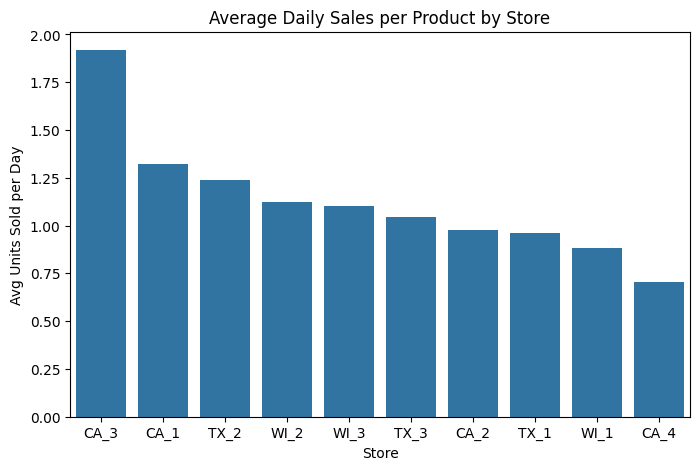

In [19]:
avg_store_sales = sales.groupby('store_id')['avg_daily_sales'].mean().sort_values(ascending = False)

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_store_sales.index, y=avg_store_sales.values)
plt.title("Average Daily Sales per Product by Store")
plt.ylabel("Avg Units Sold per Day")
plt.xlabel("Store")
plt.show()

In [3]:
import dask.dataframe as dd
import pandas as pd

# Load sales data using Dask (does not fully load into memory)
sales_dask = dd.read_csv("/Users/abhigyanseth/Projects/m5_forecasting/data/sales_train_validation.csv")

# Total number of product rows
num_rows = 30490
chunk_size = 2000  # You can try 2000 if it runs smoothly

# Output file
output_file = "sales_long_full.csv"
header_written = False

# Process data in chunks
for i in range(0, num_rows, chunk_size):
    print(f"Processing products {i} to {i + chunk_size - 1}")

    # Load chunk from Dask and convert to pandas
    chunk = sales_dask.loc[i:i + chunk_size - 1].compute()

    # Melt to long format
    chunk_melted = pd.melt(
        chunk,
        id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
        var_name='d',
        value_name='sales'
    )

    # Append chunk to output file
    chunk_melted.to_csv(output_file, mode='a', index=False, header=not header_written)
    header_written = True

Processing products 0 to 1999
Processing products 2000 to 3999
Processing products 4000 to 5999
Processing products 6000 to 7999
Processing products 8000 to 9999
Processing products 10000 to 11999
Processing products 12000 to 13999
Processing products 14000 to 15999
Processing products 16000 to 17999
Processing products 18000 to 19999
Processing products 20000 to 21999
Processing products 22000 to 23999
Processing products 24000 to 25999
Processing products 26000 to 27999
Processing products 28000 to 29999
Processing products 30000 to 31999


In [7]:
reader = pd.read_csv("sales_long_full.csv", chunksize=5_000_000)

for i, chunk in enumerate(reader):
    print(f"Merging chunk {i}...")
    merged_chunk = chunk.merge(calendar, on='d', how='left')
    merged_chunk.to_csv(f"sales_merged_chunk_{i}.csv", index=False)

Merging chunk 0...
Merging chunk 1...
Merging chunk 2...
Merging chunk 3...
Merging chunk 4...
Merging chunk 5...
Merging chunk 6...
Merging chunk 7...
Merging chunk 8...
Merging chunk 9...
Merging chunk 10...
Merging chunk 11...


In [10]:
sales_0 = pd.read_csv("/Users/abhigyanseth/Projects/m5_forecasting/data/sales_merged_chunk_0.csv")

sales_0.head()

/var/folders/3g/yctzkss146qd1vt6nc2yg9p40000gn/T/ipykernel_44114/2293758135.py:1: DtypeWarning: Columns (14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_0 = pd.read_csv("/Users/abhigyanseth/Projects/m5_forecasting/data/sales_merged_chunk_0.csv")


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


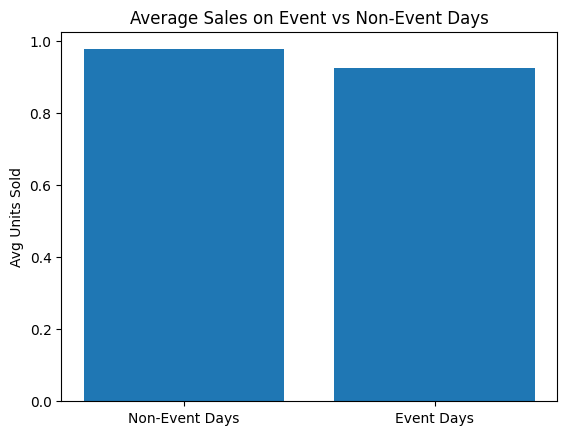

In [20]:
event_vs_nonevent_0 = sales_0.copy()

event_vs_nonevent_0['is_event'] = (
    event_vs_nonevent_0['event_name_1'].notnull() |
    event_vs_nonevent_0['event_name_2'].notnull()
)

avg_event_sales_0 = event_vs_nonevent_0.groupby('is_event')['sales'].mean()

labels = avg_event_sales_0.index.map({False: 'Non-Event Days', True: 'Event Days'})
values = avg_event_sales_0.values

plt.bar(labels, values)
plt.title("Average Sales on Event vs Non-Event Days")
plt.ylabel("Avg Units Sold")
plt.show()